<a href="https://colab.research.google.com/github/Arpita-Rajput/ProblemStatement_TredenceAnalytics/blob/main/ProblemStat_Tredence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STEP 0: Setup Environment**

*   Install required libraries





In [1]:
pip install torch torchvision matplotlib

**STEP 1: Dataset (NO manual download needed)**

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

# Transform (normalize images)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# Download training data
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,   # automatic download
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True
)

# Download test data
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False
)

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


**STEP 2: Create Prunable Linear Layer**

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()

        self.in_features = in_features
        self.out_features = out_features

        # 🔹 1. Weight parameter (same as nn.Linear)
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01
        )

        # 🔹 2. Bias parameter
        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        # 🔹 3. Gate scores (LEARNABLE)
        # same shape as weight
        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features)
        )

    def forward(self, x):
        # 🔹 Step 1: Convert scores → gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # 🔹 Step 2: Apply pruning
        pruned_weights = self.weight * gates

        # 🔹 Step 3: Linear transformation
        output = F.linear(x, pruned_weights, self.bias)

        return output

**STEP 3: Build Neural Network**

In [4]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

**STEP 4: Sparsity Loss**

In [5]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)  # L1 norm
    return loss

**STEP 5: Training Loop**

In [6]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PrunableNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

lambda_val = 1e-4   # try different values later

epochs = 10

for epoch in range(epochs):
    running_loss = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        # classification loss
        loss1 = criterion(outputs, labels)

        # sparsity loss
        loss2 = sparsity_loss(model)

        # total loss
        loss = loss1 + lambda_val * loss2

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

Epoch 1, Loss: 57490.942
Epoch 2, Loss: 38498.087
Epoch 3, Loss: 24855.638
Epoch 4, Loss: 16422.582
Epoch 5, Loss: 11440.220
Epoch 6, Loss: 8407.551
Epoch 7, Loss: 6477.199
Epoch 8, Loss: 5193.112
Epoch 9, Loss: 4306.441
Epoch 10, Loss: 3674.671


**STEP 6: Evaluate Accuracy**

In [7]:
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 56.0


**STEP 7: Calculate Sparsity**

In [8]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total


sparsity = calculate_sparsity(model)
print("Sparsity (%):", sparsity)

Sparsity (%): 36.48230057380738


**STEP 8: Plot Gate Distribution**

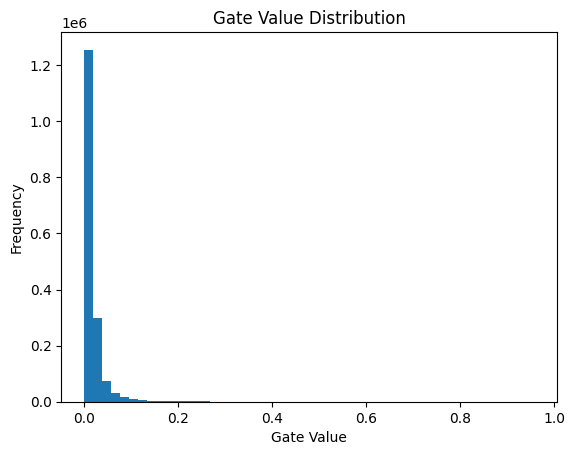

In [9]:
import matplotlib.pyplot as plt

all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
        all_gates.extend(gates.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()